In [1]:
%load_ext autoreload
%autoreload 2

import os

os.chdir("../../")

In [2]:
import pandas as pd


df = pd.read_csv("data/cleaned_human_to_human_transcripts.csv")
df

,pair_id,round_ix,transcript,llm_extracted_object_descriptions,llm_extracted_object_descriptions_updated,llm_extracted_object_descriptions_GPT_5
0,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,"{\n ""object_#1"": ""a rabbit facing to the ri...","{\n ""object_#1"": ""a rabbit facing to the ri...","{\n ""object_#1"": ""rabbit facing to the righ..."
1,3kk7u0fy_08dnx2dx_ljtwijvs,2,[18:47:04] director: hi there \n\n[18:47:11] m...,"{\n ""object_#1"": ""a rectangle basket with t...","{\n ""object_#1"": ""rectangle basket, right s...","{\n ""object_#1"": ""a rectangle basket, the r..."
2,3kk7u0fy_08dnx2dx_ljtwijvs,3,[19:05:34] director: hi there \n\n[19:05:41] m...,"{\n ""object_#1"": ""the 2 tone basket, dark b...","{\n ""object_#1"": ""the 2 tone basket, dark b...","{\n ""object_#1"": ""2 tone basket, dark brown..."
3,3kk7u0fy_08dnx2dx_ljtwijvs,4,[19:16:36] director: hi there! \n\n[19:16:42] ...,"{\n ""object_#1"": ""the shallow light colored...","{\n ""object_#1"": ""the shallow light colored...","{\n ""object_#1"": ""shallow light colored bas..."
4,3kk7u0fy_2ifxj59u_qhyb02an,1,[18:16:40] director: 1 the rabbit facing your ...,"{\n ""object_#1"": ""the rabbit facing your ri...","{\n ""object_#1"": ""the rabbit facing your ri...","{\n ""object_#1"": ""the rabbit facing your ri..."
...,...,...,...,...,...,...
123,oatjomyt_kcdph60s_nnard4ka,4,[20:14:52] director: 1. Pie \n\n[20:14:56] mat...,"{\n ""object_#1"": ""Pie"",\n ""object_#2"": ""...","{\n ""object_#1"": ""Pie"",\n ""object_#2"": ""...","{\n ""object_#1"": ""Pie"",\n ""object_#2"": ""..."
124,oatjomyt_pog2ivsb_ru7kjtls,1,[16:47:17] director: 1 looks like an animal wi...,"{\n ""object_#1"": ""looks like an animal with...","{\n ""object_#1"": ""looks like an animal with...","{\n ""object_#1"": ""looks like an animal, hea..."
125,oatjomyt_pog2ivsb_ru7kjtls,2,[17:05:53] director: 1 - brown rectangular bas...,"{\n ""object_#1"": ""brown rectangular basket ...","{\n ""object_#1"": ""brown rectangular basket ...","{\n ""object_#1"": ""brown rectangular basket ..."
126,oatjomyt_pog2ivsb_ru7kjtls,3,[17:17:41] director: very dark brown with a re...,"{\n ""object_#1"": ""very dark brown with a re...","{\n ""object_#1"": ""very dark brown with a re...","{\n ""object_#1"": ""very dark brown with a re..."


In [3]:
# from src.data.utils import pretty_print

# # pretty_print(df[(df["pair_id"] == "knco59ak_021rjj1v_eyfin1ae") & (df["round_ix"] == 1)])
# pretty_print(df.loc[[40]])

In [4]:
import json


def parse_llm_response(response):
    response = response.replace("json", "").strip()
    try:
        parsed = json.loads(response)
    except json.JSONDecodeError as e:
        print(f"JSONDecodeError: {e}")
        parsed = []
    return parsed


df["parsed_llm_response"] = df["llm_extracted_object_descriptions_GPT_5"].apply(parse_llm_response)    

In [5]:
df.head()

,pair_id,round_ix,transcript,llm_extracted_object_descriptions,llm_extracted_object_descriptions_updated,llm_extracted_object_descriptions_GPT_5,parsed_llm_response
0,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,"{\n ""object_#1"": ""a rabbit facing to the ri...","{\n ""object_#1"": ""a rabbit facing to the ri...","{\n ""object_#1"": ""rabbit facing to the righ...","{'object_#1': 'rabbit facing to the right', 'o..."
1,3kk7u0fy_08dnx2dx_ljtwijvs,2,[18:47:04] director: hi there \n\n[18:47:11] m...,"{\n ""object_#1"": ""a rectangle basket with t...","{\n ""object_#1"": ""rectangle basket, right s...","{\n ""object_#1"": ""a rectangle basket, the r...","{'object_#1': 'a rectangle basket, the right s..."
2,3kk7u0fy_08dnx2dx_ljtwijvs,3,[19:05:34] director: hi there \n\n[19:05:41] m...,"{\n ""object_#1"": ""the 2 tone basket, dark b...","{\n ""object_#1"": ""the 2 tone basket, dark b...","{\n ""object_#1"": ""2 tone basket, dark brown...","{'object_#1': '2 tone basket, dark brown body ..."
3,3kk7u0fy_08dnx2dx_ljtwijvs,4,[19:16:36] director: hi there! \n\n[19:16:42] ...,"{\n ""object_#1"": ""the shallow light colored...","{\n ""object_#1"": ""the shallow light colored...","{\n ""object_#1"": ""shallow light colored bas...",{'object_#1': 'shallow light colored basket wi...
4,3kk7u0fy_2ifxj59u_qhyb02an,1,[18:16:40] director: 1 the rabbit facing your ...,"{\n ""object_#1"": ""the rabbit facing your ri...","{\n ""object_#1"": ""the rabbit facing your ri...","{\n ""object_#1"": ""the rabbit facing your ri...","{'object_#1': 'the rabbit facing your right', ..."


In [6]:
df["parsed_llm_response"].apply(len).describe()

count    128.0
mean      12.0
std        0.0
min       12.0
25%       12.0
50%       12.0
75%       12.0
max       12.0
Name: parsed_llm_response, dtype: float64

In [7]:
df.columns

Index(['pair_id', 'round_ix', 'transcript',
       'llm_extracted_object_descriptions',
       'llm_extracted_object_descriptions_updated',
       'llm_extracted_object_descriptions_GPT_5', 'parsed_llm_response'],
      dtype='object')

In [8]:
object_filename_map = {
  "rounds": [
    {
      "round": 1,
      "baskets": [
        "076.png", "001.png", "015.png", "009.png", "022.png", "033.png",
        "012.png", "040.png", "037.png", "019.png", "065.png", "017.png"
      ]
    },
    {
      "round": 2,
      "baskets": [
        "015.png", "037.png", "001.png", "022.png", "040.png", "076.png",
        "033.png", "019.png", "012.png", "065.png", "017.png", "009.png"
      ]
    },
    {
      "round": 3,
      "baskets": [
        "012.png", "009.png", "033.png", "076.png", "017.png", "037.png",
        "001.png", "040.png", "022.png", "019.png", "065.png", "015.png"
      ]
    },
    {
      "round": 4,
      "baskets": [
        "019.png", "022.png", "076.png", "012.png", "065.png", "001.png",
        "037.png", "015.png", "033.png", "009.png", "017.png", "040.png"
      ]
    },
    {
      "fullList": [
        "076.png", "001.png", "015.png", "009.png", "022.png", "033.png",
        "012.png", "040.png", "037.png", "019.png", "065.png", "017.png",
        "005.png", "039.png", "057.png", "081.png", "077.png", "078.png"
      ]
    }
  ]
}
object_filename_map = object_filename_map["rounds"]
type(object_filename_map), len(object_filename_map)

(list, 5)

In [9]:
extracted_descriptions = []
cols = ["pair_id", "round_ix", "transcript", "object_ix", "filename", "object_description"]

for _, row in df.iterrows():
    pair_id = row["pair_id"]
    round_ix = row["round_ix"]
    transcript = row["transcript"]
    description_dict = row["parsed_llm_response"]
    for i, key in enumerate(description_dict):
        object_ix = i+1
        
        if f"object_#{object_ix}" != key:
            print(
                f"Warning: Expected object_#{object_ix} but got {key} in pair {pair_id}, round {round_ix}"
            )
            continue
        
        filename = object_filename_map[round_ix - 1]["baskets"][i]
        object_description = description_dict.get(key, None)
        extracted_descriptions.append(
            {
                "pair_id": pair_id,
                "round_ix": round_ix,
                "transcript": transcript,
                "object_ix": object_ix,
                "filename": filename,
                "object_description": object_description,
            }
        )

In [10]:
extracted_descriptions_df = pd.DataFrame(extracted_descriptions)
extracted_descriptions_df.head()

,pair_id,round_ix,transcript,object_ix,filename,object_description
0,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,1,076.png,rabbit facing to the right
1,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,2,001.png,"basic round basket, round, has a handle, unifo..."
2,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,3,015.png,"rectangle, right side of the lid is propped op..."
3,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,4,009.png,"2 tone white and light brown, the handle comes..."
4,3kk7u0fy_08dnx2dx_ljtwijvs,1,[18:27:25] director: Hi there. The first baske...,5,022.png,"fairly basic, uniform brown color, a braided h..."


In [11]:
extracted_descriptions_df.to_csv(
    "data/llm_extracted_object_descriptions_parsed.csv", index=False
)

In [12]:
import re


STOP_WORDS = ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 
              'and', 'any', 'are', "aren't", 'as', 'at', 'be', 'because', 'been', 
              'before', 'being', 'below', 'between', 'both', 'but', 'by', "can't", 
              'cannot', 'could', "couldn't", 'did', "didn't", 'do', 'does', "doesn't", 
              'doing', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 
              'had', "hadn't", 'has', "hasn't", 'have', "haven't", 'having', 'he', "he'd", 
              "he'll", "he's", 'her', 'here', "here's", 'hers', 'herself', 'him', 'himself', 
              'his', 'how', "how's", 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 
              "isn't", 'it', "it's", 'its', 'itself', "let's", 'me', 'more', 'most', "mustn't", 'my', 
              'myself', 'no', 'nor', 'not', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'ought', 
              'our', 'ours', 'ourselves', 'out', 'over', 'own', 'same', "shan't", 'she', "she'd", "she'll", 
              "she's", 'should', "shouldn't", 'so', 'some', 'such', 'than', 'that', "that's", 'the', 'their', 
              'theirs', 'them', 'themselves', 'then', 'there', "there's", 'these', 'they', "they'd", "they'll", 
              "they're", "they've", 'this', 'those', 'through', 'to', 'too', 'under', 'until', 'up', 'very', 
              'was', "wasn't", 'we', "we'd", "we'll", "we're", "we've", 'were', "weren't", 'what', "what's", 'when', 
              "when's", 'where', "where's", 'which', 'while', 'who', "who's", 'whom', 'why', "why's", 'with', "won't", 
              'would', "wouldn't", 'you', "you'd", "you'll", "you're", "you've", 'your', 'yours', 'yourself', 'yourselves']

def preprocess_text(text: str) -> str:
    # remove punctuation and lowercase
    text = re.sub(r"[^\w\s]", "", text.lower())

    if not isinstance(text, str):
        return ""
    
    tokens = re.findall(r"\b\w+\b", text)
    filtered = [t for t in tokens if t not in STOP_WORDS]
    return " ".join(filtered)

In [13]:
# extracted_descriptions_df["object_description_preprocessed"] = extracted_descriptions_df["object_description"].apply(preprocess_text)

In [14]:
extracted_descriptions_piv = extracted_descriptions_df.pivot(
    index=["pair_id", "filename"],
    columns="round_ix",
    values="object_description"
)
extracted_descriptions_piv


round_ix                                                                             1  \
pair_id                    filename                                                      
3kk7u0fy_08dnx2dx_ljtwijvs 001.png   basic round basket, round, has a handle, unifo...   
                           009.png   2 tone white and light brown, the handle comes...   
                           012.png   2 tone, darker and lighter brown, the handle a...   
                           015.png   rectangle, right side of the lid is propped op...   
                           017.png   looks like a purse or a tote bag, has a slight...   
...                                                                                ...   
oatjomyt_pog2ivsb_ru7kjtls 033.png   another animal-like one, face looking straight...   
                           037.png   the tallest one, it's facing forward, you can ...   
                           040.png   top and bottom of basket are greyish, middle o...   
                           065.png   brown, tight weave, round, round handle on the...   
                           076.png      looks like an animal, head facing to the right   

round_ix                                                                             2  \
pair_id                    filename                                                      
3kk7u0fy_08dnx2dx_ljtwijvs 001.png   a very standard round basket, uniform brown co...   
                           009.png   the light brown and white basket with the hand...   
                           012.png   a 2 tone rectangle basket, dark brown body wit...   
                           015.png   a rectangle basket, the right side of the lid ...   
                           017.png   looks like a purse or a tote bag with a slight...   
...                                                                                ...   
oatjomyt_pog2ivsb_ru7kjtls 033.png                the animal one facing straight ahead   
                           037.png   tall round basket, looks like small round hand...   
                           040.png   lighter stripe, greyish, on top and bottom of ...   
                           065.png   round basket, brown, tight weave, with a round...   
                           076.png                  the animal-like one, facing right'   

round_ix                                                                             3  \
pair_id                    filename                                                      
3kk7u0fy_08dnx2dx_ljtwijvs 001.png   uniform brown basket, slightly taller round bo...   
                           009.png   light brown and white basket, handles that spl...   
                           012.png   2 tone basket, dark brown body with lighter br...   
                           015.png   rectangle basket, right side of the lid open a...   
                           017.png   uniform brown basket, reminds me of a purse or...   
...                                                                                ...   
oatjomyt_pog2ivsb_ru7kjtls 033.png             animal with face looking straight ahead   
                           037.png   tall brown basket, round, small round handles,...   
                           040.png   has a greyish stripe on top and bottom, center...   
                           065.png                   very skinny basket, left to right   
                           076.png                         animal looking to the right   

round_ix                                                                             4  
pair_id                    filename                                                     
3kk7u0fy_08dnx2dx_ljtwijvs 001.png   a uniform brown basket, very nicely arched han...  
                           009.png   the 2 tone basket that is light brown and whit...  
                           012.png   a 2 tone basket, dark body and more reddish br...  
                           015.png   the r

In [15]:
round_cols = [1, 2, 3, 4]


extracted_descriptions_piv_agg = (
    extracted_descriptions_piv
    .groupby('pair_id')[round_cols]
    .agg(lambda x: ' '.join(x.dropna().astype(str)))
    .reset_index()
)

extracted_descriptions_piv_agg

round_ix,pair_id,1,2,3,4
0,3kk7u0fy_08dnx2dx_ljtwijvs,"basic round basket, round, has a handle, unifo...","a very standard round basket, uniform brown co...","uniform brown basket, slightly taller round bo...","a uniform brown basket, very nicely arched han..."
1,3kk7u0fy_2ifxj59u_qhyb02an,"the very smooth brown one, has the smoothest b...",is the shiniest in all brown the handle has br...,the all brown shiny one the handle and body ha...,"the shiniest of them all, has one handle has b..."
2,3kk7u0fy_2ivt4mpj_g7urxzlh,"oval shaped basked with a handle, oblong baske...","oval shaped, doesn't look like wicker, its a m...","round and doesn't look like wicker, one handle...","the one that doesn't appear to be wicker, roun..."
3,3kk7u0fy_ddls1zzn_ldgryt73,"dark brown with a handle, the bottom is more r...","the round basket, has a shine to it has 2 hand...","has a shine to it, has a rounded bottom, its b...","has a shine to it, the handle is darker than t..."
4,3kk7u0fy_ecjbn129_fkm1onm5,"darker brown, normal handle light brown, its a...","dark brown, angled handle right to left, front...","darker brown one color, looks like a bucket al...","looks like a bucket, handle slightly darker 2 ..."
5,3kk7u0fy_h25858cf_lp93p3bc,"bucket like design, acorn like, an upside down...","looks like upside down biker helmet, it's all ...","biker helemt upside down, all medium brown bas...",the upside down biker helemt with strap white ...
6,3kk7u0fy_kg97cklp_uklqrrvj,"has a smooth texture and handle, looks like a ...",the copper bowl one. the white stripe with the...,shiny copper one the white wrapped handle one ...,copper bowl white striped with wrapped handles...
7,3kk7u0fy_mzq0l3en_p5uvrh8a,smooth basket band on the handle square shaped...,"basket with the smoothest base, smooth body wh...",smoothest basket handle with band middle dark ...,smoothest body basket white band on handle bas...
8,3kk7u0fy_r5xmex9c_vpm4e0mw,brown basket with a tight weave and circular h...,brown round with tight weave round handle two ...,brown round with tight weave light two tone wi...,round brown with tight weave two tone with fou...
9,3kk7u0fy_s9f6kam4_yzyxz2ce,the smooth round basket the basket with white ...,the basket that looks smooth the white and bro...,looks more smooth brown and white striped one ...,the one that looks very smooth the brown and w...


In [16]:
extracted_descriptions_piv_agg.shape

(32, 5)

In [17]:
extracted_descriptions_piv.to_csv(
    "data/llm_extracted_object_descriptions_parsed_pivoted.csv"
    )

In [18]:
from src.data.utils import pretty_print


pretty_print(extracted_descriptions_piv.sample(4))

,round_ix,1,2,3,4
pair_id,filename,,,,
knco59ak_p3z9x797_w6eqf2bc,017.png,"looks like a basket you might take shopping, it has a braid around the top of the basket part, it's oval-ish, solid","shopping basket, braid around the rim, swoopy, not straight",swoopy shopping basket,swoopy shopping basket
3kk7u0fy_ecjbn129_fkm1onm5,012.png,"almost like number 5, 2 different colors, less of an opening as number 5","2 colors, darker in the middle, straight on view","2 colors, darker in middle, facing direct, rectangle","2 colors, darker in the middle, looking direct, rectangle"
3kk7u0fy_kg97cklp_uklqrrvj,012.png,"black in the middle and a redish brown handle and top and bottom rim, it's oblong, similar shape to picnic basket",the black one with brown top and bottom and brown handle.,black basket with brown handle,black with brown handle
knco59ak_esgfbf8h_tyn00k1z,019.png,"a wide, shallow, round open basket with a light colored handle and base, featuring a contrasting, distinct horizontal band of dark reddish brown wicker around the lower side walls",the most shallow basket with light cream color,the most shallow basket,most shallow


In [19]:
sub = extracted_descriptions_df[extracted_descriptions_df["object_description"] == ""]
sub

,pair_id,round_ix,transcript,object_ix,filename,object_description
488,knco59ak_021rjj1v_eyfin1ae,1,[17:19:44] director: rabbit looking basket \n\...,9,037.png,
489,knco59ak_021rjj1v_eyfin1ae,1,[17:19:44] director: rabbit looking basket \n\...,10,019.png,
490,knco59ak_021rjj1v_eyfin1ae,1,[17:19:44] director: rabbit looking basket \n\...,11,065.png,
491,knco59ak_021rjj1v_eyfin1ae,1,[17:19:44] director: rabbit looking basket \n\...,12,017.png,
733,knco59ak_d42tx12m_or8l74is,2,[22:00:38] director: the first basket was the ...,2,037.png,
780,knco59ak_esgfbf8h_tyn00k1z,2,[17:20:28] director: you the same guy that we ...,1,015.png,
935,knco59ak_mzlq24zh_yilrr2uq,2,[18:45:20] director: 1. basket has 2 lids with...,12,009.png,
1151,oatjomyt_1mt2iezs_ksg9e819,4,[17:29:46] director: flat/shallow round basket...,12,040.png,


### Compute RED metrics

In [20]:
from src.evals.red import compute_red_metrics


In [21]:
# df_items, df_summary = compute_red_metrics(extracted_descriptions_piv, group_cols=["pair_id"])
# exclude index that has pair_id=knco59ak_021rjj1v_eyfin1ae in extracted_descriptions_piv
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv)

In [22]:
df_summary

,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,0.126494,-0.003508,0.123697,0.259293,0.547743,0.652733,0.570846


In [54]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv, group_cols=["pair_id"])
df_summary

,pair_id,RALR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,3kk7u0fy_08dnx2dx_ljtwijvs,-0.179584,-0.220375,0.305556,0.721580,0.570633
1,3kk7u0fy_2ifxj59u_qhyb02an,0.082168,-0.125340,0.333333,0.658333,0.597222
2,3kk7u0fy_2ivt4mpj_g7urxzlh,-0.152701,-0.028704,0.444444,0.643540,0.502414
3,3kk7u0fy_ddls1zzn_ldgryt73,0.085055,0.269463,0.500000,0.719062,0.677421
4,3kk7u0fy_ecjbn129_fkm1onm5,-0.118968,0.103054,0.388889,0.686086,0.521263
5,3kk7u0fy_h25858cf_lp93p3bc,-0.425737,-0.352441,0.361111,0.584083,0.447685
6,3kk7u0fy_kg97cklp_uklqrrvj,0.608355,0.677473,0.638889,0.732021,0.668056
7,3kk7u0fy_mzq0l3en_p5uvrh8a,-0.185648,-0.140741,0.277778,0.780688,0.601687
8,3kk7u0fy_r5xmex9c_vpm4e0mw,0.050000,-0.113889,0.222222,0.699074,0.637103
9,3kk7u0fy_s9f6kam4_yzyxz2ce,-0.255203,-0.230820,0.277778,0.566353,0.450000


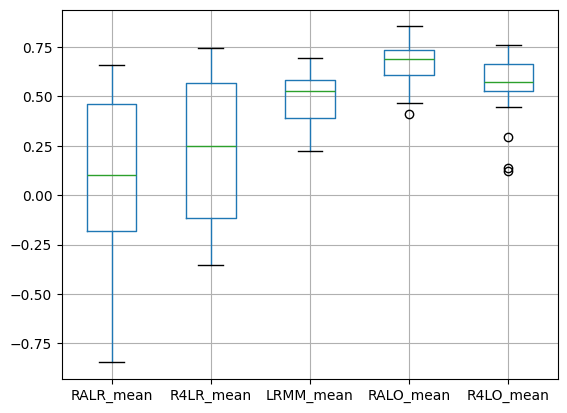

In [55]:
import matplotlib.pyplot as plt
df_summary.boxplot(column=["RALR_mean", "R4LR_mean", "LRMM_mean", "RALO_mean", "R4LO_mean"])
plt.show()

In [30]:
from src.data.utils import pretty_print

pretty_print(df_items.sample(5))

,round_ix,1,2,3,4,len_RED1,len_RED2,len_RED3,len_RED4,RALR,R4LR,LRMM,RALO,R4LO
pair_id,filename,,,,,,,,,,,,,
knco59ak_6hwoscz8_gdoo1cr3,022.png,"medium brown, The basket part of it is short and the handle is big, You can see very little of the inside, just the interior of the lip farthest away from us, The rim of the basket and the handle are slightly lighter brown than the rest of it","it's a wide basket that has a large handle, We are facing the wide side of it, The basket itself is a little darker brown than the rim and the handle, You can see the interior of the opposite rim a little bit","wide basket with short basket area and a large handle, The handle goes straight up and then curves and goes straight across","wide basket with large handle, The handle goes straight up, then curves, then goes straight across, You can only see a little of the interior",49,43,22,25,0.387755,0.489796,0.666667,0.539091,0.440000
knco59ak_hjrv83g6_pe41te3z,033.png,"rabbit face on, has 2 little feet",rabbit facing straight on 2 littel feet,"rabbit face on, 2 little feet",rabbit straight on 2 little feet,7,7,6,6,0.095238,0.142857,0.333333,0.690476,0.833333
3kk7u0fy_ddls1zzn_ldgryt73,015.png,"handle is in the middle, has 2 sides, the right side is open, its light brown","handle is in the middle, it has 2 sides, the right side is open","the handle is in the middle, there are 2 sides, the right side is open","handle is in the middle, has 2 sides, the right side is open",16,14,15,13,0.125000,0.187500,0.666667,0.883883,1.000000
oatjomyt_pog2ivsb_ru7kjtls,009.png,"rectangular basket, lighter weave in the middle, almost a double handle, reddish-brown, handle is solid right at the top, turns into two on each side, upside-down V as it connects to the basket, all brown, tightly wovem, light stripe in the center",very light in the center part and light brown stripe on top and bottom. the handle is rounded at the very top and splits into an upside down V where it attaches to the basket,"very light, greyish center, rectangular with darker stripe on top and bottom, handle is rounded in the center and curves down to an upside down V where it attaches to the basket, actually 2 upside down Vs, one on each side","rectangular, greyish center with a reddish-brown stripe on top and bottom, handles comes to an inverted V on either side where it attachees",42,35,41,23,0.214286,0.452381,0.666667,0.617344,0.500000
oatjomyt_6l7mq2vy_sver4gh9,076.png,looks like a rabbit,Rabbit,rabbit,Rabbit,4,1,1,1,0.750000,0.750000,0.333333,1.000000,1.000000


In [56]:
df_items[["RALR", "R4LR", "LRMM", "RALO", "R4LO"]].describe()

round_ix,RALR,R4LR,LRMM,RALO,R4LO
count,380.000000,380.000000,384.000000,380.000000,383.000000
mean,0.102068,0.221115,0.490451,0.668651,0.563397
std,0.812063,0.765933,0.247813,0.189210,0.308804
min,-7.222222,-7.333333,0.000000,0.000000,0.000000
25%,-0.063542,0.000000,0.333333,0.528312,0.333333
50%,0.272727,0.375000,0.333333,0.681944,0.526316
75%,0.555556,0.666667,0.666667,0.800000,0.800000
max,0.916667,1.000000,1.000000,1.000000,1.000000


### Aggregate

In [23]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv_agg)
df_summary

,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,0.275928,0.152477,0.27359,0.401718,0.78125,0.741792,0.70671


In [58]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv_agg, group_cols=["pair_id"])
df_summary

/tmp/ipykernel_1440446/2542010152.py:154: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_overall = d.groupby(group_cols, dropna=False).apply(summarize).reset_index()


,pair_id,RALR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,3kk7u0fy_08dnx2dx_ljtwijvs,-0.102981,-0.105691,0.333333,0.744460,0.639706
1,3kk7u0fy_2ifxj59u_qhyb02an,0.374074,0.411111,0.666667,0.806635,0.754717
2,3kk7u0fy_2ivt4mpj_g7urxzlh,0.233333,0.340000,1.000000,0.729542,0.666667
3,3kk7u0fy_ddls1zzn_ldgryt73,0.147343,0.304348,1.000000,0.778096,0.833333
4,3kk7u0fy_ecjbn129_fkm1onm5,0.051282,0.243590,0.666667,0.727643,0.644068
5,3kk7u0fy_h25858cf_lp93p3bc,-0.328947,-0.276316,0.333333,0.597762,0.474227
6,3kk7u0fy_kg97cklp_uklqrrvj,0.622951,0.729508,1.000000,0.741265,0.757576
7,3kk7u0fy_mzq0l3en_p5uvrh8a,-0.111111,-0.066667,0.333333,0.770704,0.625000
8,3kk7u0fy_r5xmex9c_vpm4e0mw,0.122449,-0.020408,0.666667,0.720171,0.640000
9,3kk7u0fy_s9f6kam4_yzyxz2ce,0.005848,0.070175,0.333333,0.645575,0.584906


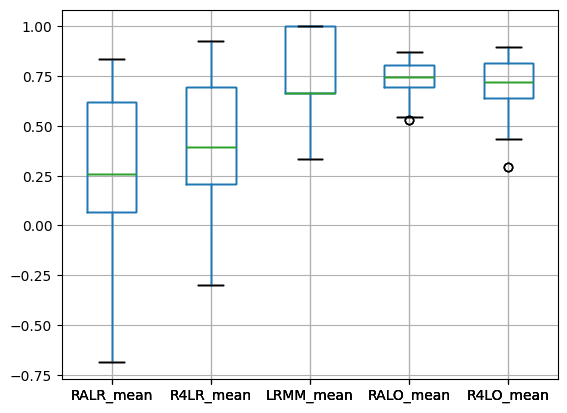

In [39]:
import matplotlib.pyplot as plt
df_summary.boxplot(column=["RALR_mean", "R4LR_mean", "LRMM_mean", "RALO_mean", "R4LO_mean"])
plt.show()